In [26]:
# !unzip -o ./Data/cassava-disease.zip -d ./Data/
# !unzip -o ./Data/train.zip -d ./Data/
# !unzip -o ./Data/test.zip -d ./Data/

In [27]:
%matplotlib inline

In [28]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from PIL import Image
import os
from pathlib import Path
from icecream import ic

## Data Preparing

In [29]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [30]:
train_dataset = datasets.ImageFolder(root="./Data/train", transform=transform_train)
test_dataset = datasets.ImageFolder(root="./Data/test", transform=transform_test)

train_dataset.class_to_idx

{'cbb': 0, 'cbsd': 1, 'cgm': 2, 'cmd': 3, 'healthy': 4}

In [31]:
len(train_dataset)

5656

In [32]:
train_dataset[0][0].shape

torch.Size([3, 256, 256])

In [33]:
labels = [train_dataset[i][1] for i in trange(len(train_dataset))]
train_idx, val_idx = train_test_split(range(len(train_dataset)), stratify=labels, test_size=0.3, random_state=42)

100%|██████████| 5656/5656 [00:24<00:00, 226.68it/s]


In [34]:
train_idx[:10], val_idx[:10]

([2450, 3490, 1885, 1352, 4373, 1281, 4082, 2885, 297, 1471],
 [3823, 4969, 3786, 1652, 862, 4062, 1005, 5469, 462, 1683])

In [35]:
len(train_idx), len(val_idx)

(3959, 1697)

In [36]:
train_data = torch.utils.data.Subset(train_dataset, train_idx)
val_data = torch.utils.data.Subset(train_dataset, val_idx)

In [37]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=8, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False, num_workers=8, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, persistent_workers=True)

In [38]:
def show_images(images, labels):
    f, axes= plt.subplots(1, 10, figsize=(30,5))

    for i, axis in enumerate(axes):
        # переводим картинку из тензора в numpy
        img = images[i].numpy()
        # переводим картинку в размерность (длина, ширина, цветовые каналы)
        img = np.transpose(img, (1, 2, 0))

        axes[i].imshow(img)
        axes[i].set_title(labels[i].numpy())

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3935575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9749122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].

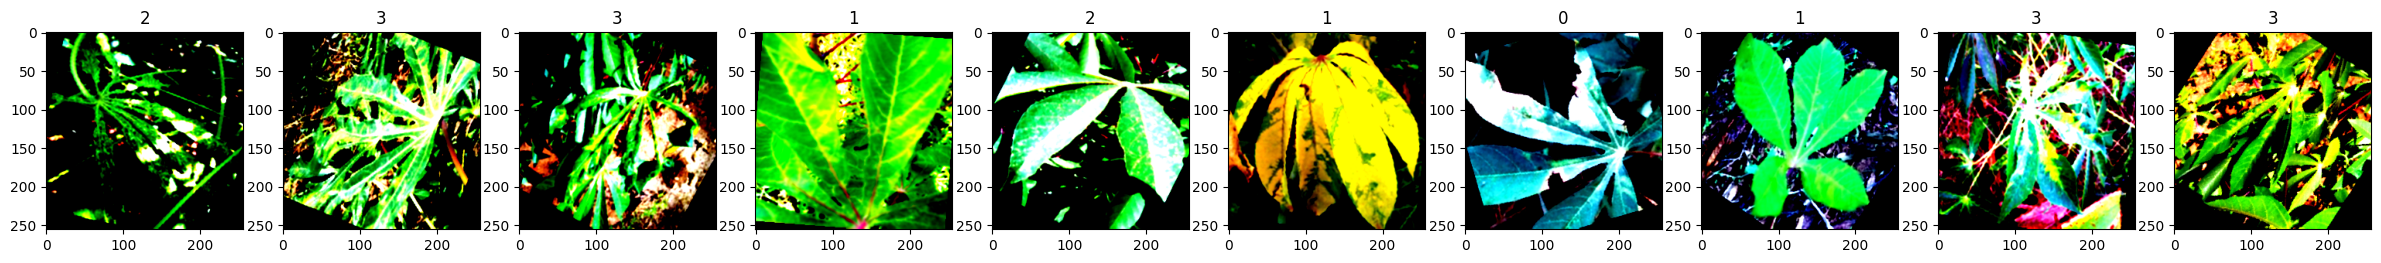

In [41]:
for batch in train_loader:
    # батч картинок и батч ответов к картинкам
    images, labels = batch
    break

show_images(images, labels)

## Model

In [42]:
class CassavaClassifier(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            output_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(CassavaClassifier, self).__init__()

        conv_layers = [
            nn.Conv2d(in_channels=in_ch, out_channels=hidden_ch[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU()
            # nn.Dropout2d(conv_dropout)
        ]

        last_dim = hidden_ch[0]

        for i in range(1, len(hidden_ch)):
            conv_layers.extend([
                nn.Conv2d(in_channels=last_dim, out_channels=hidden_ch[i], kernel_size=3, padding=1),
                nn.BatchNorm2d(hidden_ch[i]),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            last_dim = hidden_ch[i]
        
        self.conv_part = nn.Sequential(*conv_layers)

        fc_layers = []

        last_dim = self._after_conv_shape(img_shape, self.conv_part)
        
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(fc_dropout)
            ])
            last_dim = dim

        fc_layers.extend([
            nn.Linear(last_dim, output_dim)
        ])
        
        self.fc_part = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv_part(x)
        flaten = nn.Flatten()
        x = flaten(x)
        x = self.fc_part(x)
        return x

    def _after_conv_shape(self, img_shape, conv_part) -> np.array:
        X = torch.Tensor(size=[1, *img_shape])
        flat = nn.Flatten()
        X_out = flat(conv_part(X))
        return X_out[0].shape[0]

CassavaClassifier(
    img_shape=(3, 128, 128),
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[128, 64],
    output_dim=5
)

CassavaClassifier(
  (conv_part): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout2d(p=0.2, inplace=False)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.2, inplace=False)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_part): Sequential(
    (0): Linear(in_features=131072, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, tr

## Train

In [ ]:
import os
from tqdm import trange
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def train(
    train_loader: DataLoader,
    val_loader: DataLoader,
    model: nn.Module,
    optimizer: torch.optim.AdamW,
    criterion=nn.CrossEntropyLoss(),
    num_epochs=100
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    os.makedirs("./models", exist_ok=True)

    train_losses = []
    val_losses = []
    val_metric = []
    best_accuracy = 0.0

    for epoch in trange(num_epochs):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        cur_val_loss = 0.0
        cur_pred_true = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                y_pred = model(X_batch)
                cur_val_loss += criterion(y_pred, y_batch).item()
                cur_pred_true += (y_pred.argmax(1) == y_batch).sum().item()

        val_losses.append(cur_val_loss / len(val_loader))
        cur_accuracy = cur_pred_true / len(val_loader.dataset)
        val_metric.append(cur_accuracy)

        print(f"Epoch {epoch}: Train Loss = {epoch_train_loss/len(train_loader):.4f}, "
              f"Val Loss = {cur_val_loss/len(val_loader):.4f}, "
              f"Val Acc = {cur_accuracy:.4f}")

        if len(val_metric) == 0 or cur_accuracy >= best_accuracy:
            best_accuracy = cur_accuracy
            torch.save(model.state_dict(), "./models/best_model2.pth")
            print("Best model saved!")

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label="Train")
            axs[0].plot(val_losses, label="Validation")
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("Validation Accuracy")
            axs[1].plot(val_metric)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    return model

ic| CassavaClassifier(
        img_shape=(3, 256, 256),
        in_ch=3,
        hidden_ch=[32, 64, 128, 256],
        hidden_fc=[256, 128, 64],
        output_dim=5
    ): CassavaClassifier(
         (conv_part): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (5): ReLU()
           (6): Dropout2d(p=0.2, inplace=False)
           (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (10): ReLU()
           (11): Dropout2d(p=0

Epoch 0: Train Loss = 1.3683, Val Loss = 1.1780, Val Acc = 0.5622
Best model saved!


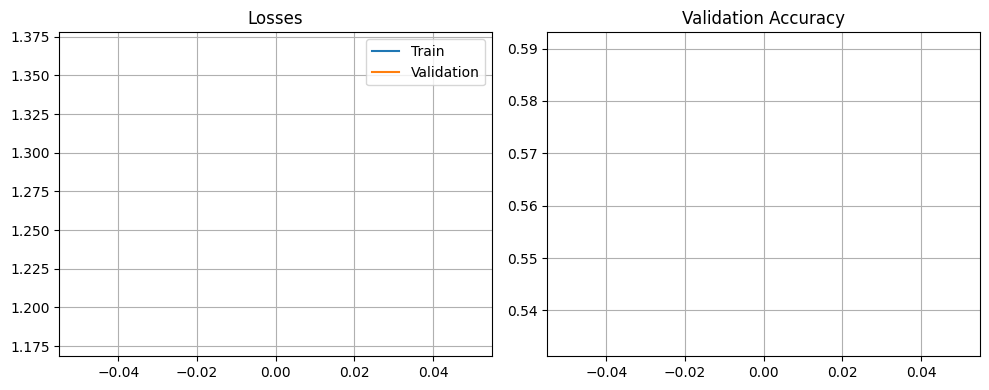

  1%|          | 1/100 [00:18<31:10, 18.89s/it]

Epoch 1: Train Loss = 1.2172, Val Loss = 1.1266, Val Acc = 0.5834


  2%|▏         | 2/100 [00:37<30:13, 18.51s/it]

Best model saved!
Epoch 2: Train Loss = 1.1515, Val Loss = 1.0635, Val Acc = 0.6229


  3%|▎         | 3/100 [00:55<29:43, 18.39s/it]

...

Epoch 7: Train Loss = 1.0382, Val Loss = 0.9964, Val Acc = 0.6311
Epoch 8: Train Loss = 1.0373, Val Loss = 0.9893, Val Acc = 0.6352


  9%|▉         | 9/100 [02:42<27:14, 17.96s/it]

Best model saved!
Epoch 9: Train Loss = 1.0183, Val Loss = 0.9640, Val Acc = 0.6464


 10%|█         | 10/100 [03:00<27:05, 18.06s/it]

Best model saved!
Epoch 10: Train Loss = 1.0209, Val Loss = 0.9473, Val Acc = 0.6488
Best model saved!


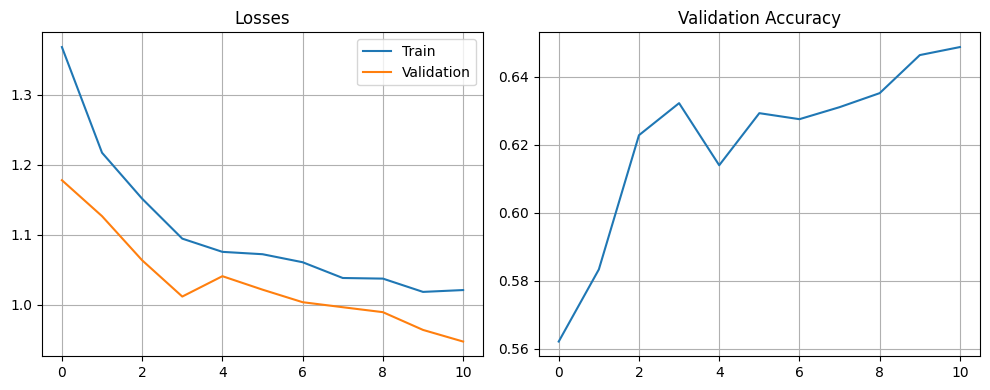

 11%|█         | 11/100 [03:19<26:57, 18.17s/it]

Epoch 11: Train Loss = 1.0059, Val Loss = 0.9556, Val Acc = 0.6541


 12%|█▏        | 12/100 [03:37<26:41, 18.20s/it]

Best model saved!


 13%|█▎        | 13/100 [03:55<26:11, 18.06s/it]

...

Epoch 17: Train Loss = 0.9659, Val Loss = 0.9419, Val Acc = 0.6612


 19%|█▉        | 19/100 [05:42<24:00, 17.79s/it]

Epoch 18: Train Loss = 0.9583, Val Loss = 0.9301, Val Acc = 0.6600


 20%|██        | 20/100 [05:59<23:40, 17.76s/it]

Epoch 19: Train Loss = 0.9595, Val Loss = 0.9378, Val Acc = 0.6594
Epoch 20: Train Loss = 0.9598, Val Loss = 0.9249, Val Acc = 0.6612


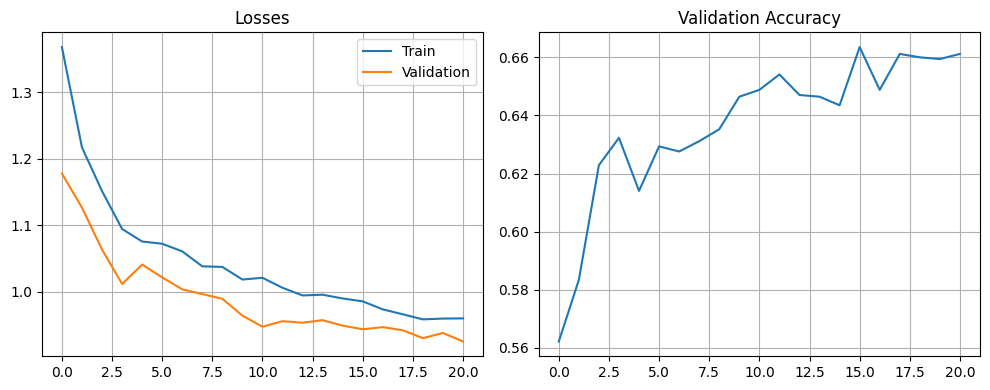

 21%|██        | 21/100 [06:17<23:23, 17.77s/it]

Epoch 21: Train Loss = 0.9648, Val Loss = 0.9061, Val Acc = 0.6659


 22%|██▏       | 22/100 [06:35<23:17, 17.92s/it]

Best model saved!


 23%|██▎       | 23/100 [06:53<22:54, 17.85s/it]

...

Epoch 27: Train Loss = 0.9185, Val Loss = 0.9249, Val Acc = 0.6629


 29%|██▉       | 29/100 [08:40<21:01, 17.76s/it]

Epoch 28: Train Loss = 0.9136, Val Loss = 0.9115, Val Acc = 0.6665


 30%|███       | 30/100 [08:57<20:42, 17.75s/it]

Epoch 29: Train Loss = 0.9167, Val Loss = 0.9028, Val Acc = 0.6511
Epoch 30: Train Loss = 0.9072, Val Loss = 0.9111, Val Acc = 0.6565


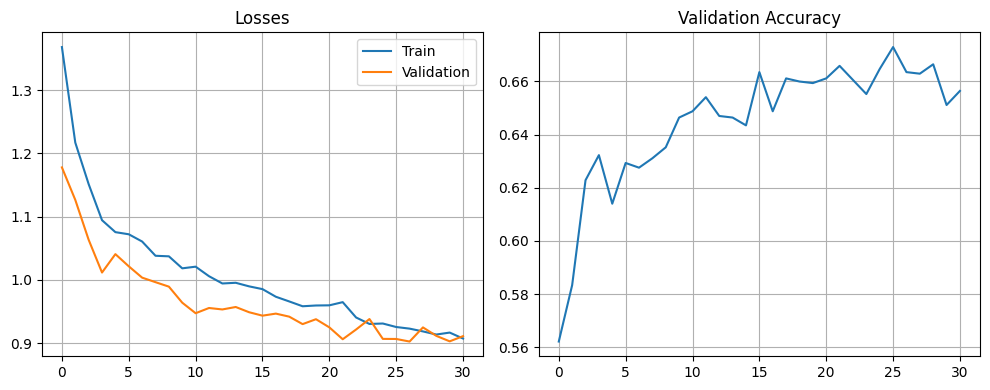

 32%|███▏      | 32/100 [09:33<20:05, 17.73s/it]

Epoch 31: Train Loss = 0.9190, Val Loss = 0.9348, Val Acc = 0.6405


 33%|███▎      | 33/100 [09:51<19:47, 17.72s/it]

Epoch 32: Train Loss = 0.8925, Val Loss = 0.9004, Val Acc = 0.6647


 34%|███▍      | 34/100 [10:08<19:28, 17.70s/it]

...

Epoch 37: Train Loss = 0.8764, Val Loss = 0.8917, Val Acc = 0.6612


 39%|███▉      | 39/100 [11:37<17:58, 17.68s/it]

Epoch 38: Train Loss = 0.8679, Val Loss = 0.9241, Val Acc = 0.6612


 40%|████      | 40/100 [11:54<17:40, 17.68s/it]

Epoch 39: Train Loss = 0.8749, Val Loss = 0.8924, Val Acc = 0.6682
Epoch 40: Train Loss = 0.8602, Val Loss = 0.9163, Val Acc = 0.6600


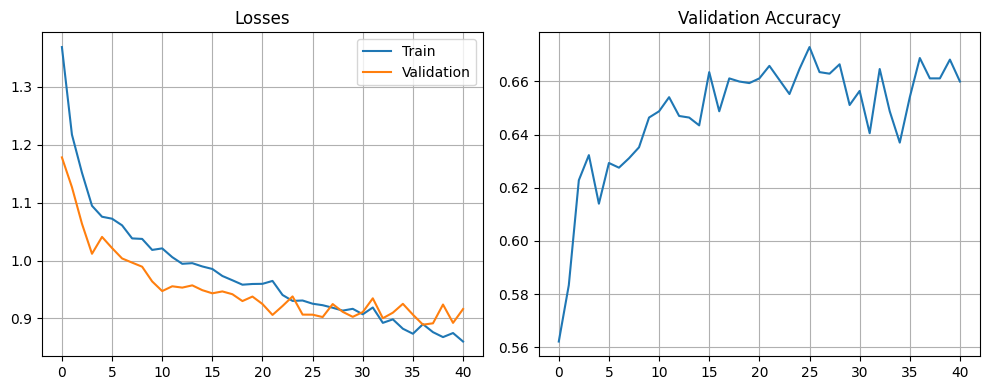

 42%|████▏     | 42/100 [12:30<17:06, 17.70s/it]

Epoch 41: Train Loss = 0.8448, Val Loss = 0.8847, Val Acc = 0.6629
Epoch 42: Train Loss = 0.8555, Val Loss = 0.8812, Val Acc = 0.6735


 43%|████▎     | 43/100 [12:48<16:58, 17.87s/it]

Best model saved!
Epoch 43: Train Loss = 0.8339, Val Loss = 0.8698, Val Acc = 0.6759


 44%|████▍     | 44/100 [13:06<16:47, 17.99s/it]

...

Best model saved!


 49%|████▉     | 49/100 [14:36<15:17, 17.99s/it]

Epoch 48: Train Loss = 0.8047, Val Loss = 0.8851, Val Acc = 0.6735


 50%|█████     | 50/100 [14:54<14:54, 17.89s/it]

Epoch 49: Train Loss = 0.8127, Val Loss = 0.8783, Val Acc = 0.6730
Epoch 50: Train Loss = 0.8004, Val Loss = 0.9341, Val Acc = 0.6618


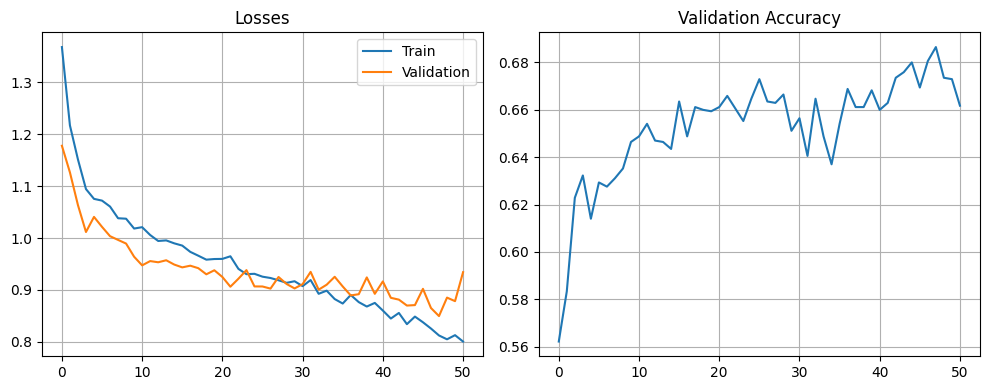

 52%|█████▏    | 52/100 [15:30<14:15, 17.82s/it]

Epoch 51: Train Loss = 0.7978, Val Loss = 0.8360, Val Acc = 0.6783


 53%|█████▎    | 53/100 [15:47<13:55, 17.78s/it]

Epoch 52: Train Loss = 0.7883, Val Loss = 0.8556, Val Acc = 0.6759
Epoch 53: Train Loss = 0.7835, Val Loss = 0.8631, Val Acc = 0.6900


 54%|█████▍    | 54/100 [16:06<13:44, 17.92s/it]

...

Best model saved!


 59%|█████▉    | 59/100 [17:35<12:11, 17.85s/it]

Epoch 58: Train Loss = 0.7522, Val Loss = 0.8710, Val Acc = 0.6818


 60%|██████    | 60/100 [17:52<11:51, 17.79s/it]

Epoch 59: Train Loss = 0.7369, Val Loss = 0.8399, Val Acc = 0.6883
Epoch 60: Train Loss = 0.7325, Val Loss = 0.8363, Val Acc = 0.6883


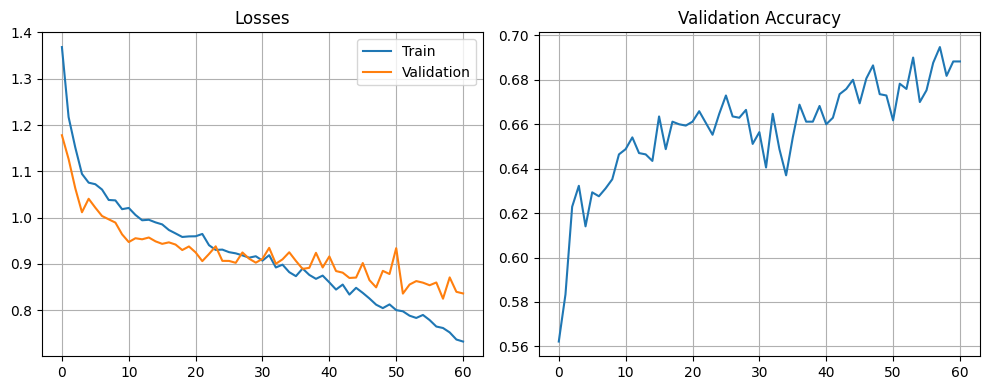

 61%|██████    | 61/100 [18:10<11:33, 17.79s/it]

Epoch 61: Train Loss = 0.7307, Val Loss = 0.8213, Val Acc = 0.7018


 62%|██████▏   | 62/100 [18:28<11:21, 17.93s/it]

Best model saved!


 63%|██████▎   | 63/100 [18:46<11:00, 17.85s/it]

...

Epoch 67: Train Loss = 0.6966, Val Loss = 0.8386, Val Acc = 0.6688
Epoch 68: Train Loss = 0.6910, Val Loss = 0.7875, Val Acc = 0.7107


 69%|██████▉   | 69/100 [20:33<09:16, 17.96s/it]

Best model saved!
Epoch 69: Train Loss = 0.6882, Val Loss = 0.7673, Val Acc = 0.7230


 70%|███████   | 70/100 [20:51<09:01, 18.05s/it]

Best model saved!
Epoch 70: Train Loss = 0.6658, Val Loss = 0.7825, Val Acc = 0.7042


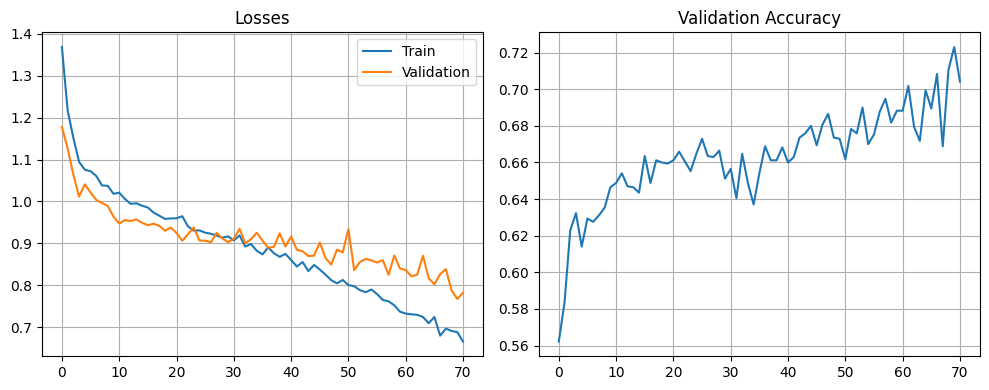

 72%|███████▏  | 72/100 [21:27<08:20, 17.89s/it]

Epoch 71: Train Loss = 0.6583, Val Loss = 0.7963, Val Acc = 0.7077


 73%|███████▎  | 73/100 [21:45<08:00, 17.81s/it]

Epoch 72: Train Loss = 0.6756, Val Loss = 0.7988, Val Acc = 0.6930


 74%|███████▍  | 74/100 [22:02<07:42, 17.77s/it]

...

Epoch 77: Train Loss = 0.6307, Val Loss = 0.7999, Val Acc = 0.6942


 79%|███████▉  | 79/100 [23:31<06:11, 17.69s/it]

Epoch 78: Train Loss = 0.6062, Val Loss = 0.8300, Val Acc = 0.6948


 80%|████████  | 80/100 [23:48<05:53, 17.68s/it]

Epoch 79: Train Loss = 0.6038, Val Loss = 0.7804, Val Acc = 0.7042
Epoch 80: Train Loss = 0.5868, Val Loss = 0.8130, Val Acc = 0.7054


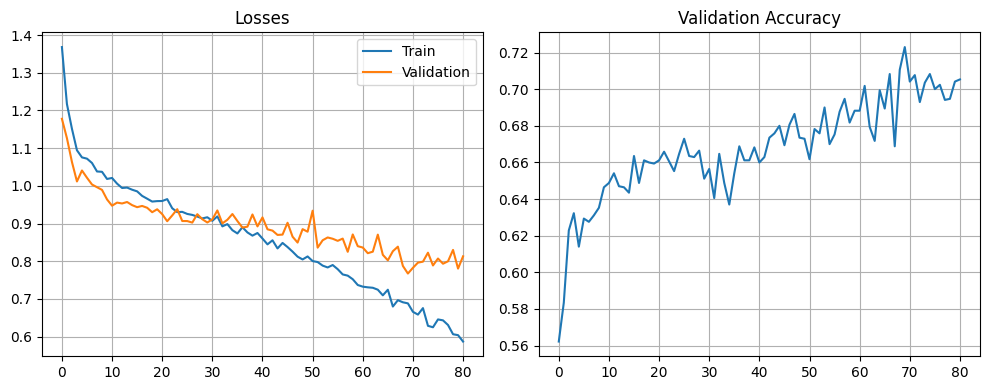

 82%|████████▏ | 82/100 [24:24<05:18, 17.70s/it]

Epoch 81: Train Loss = 0.6032, Val Loss = 0.8199, Val Acc = 0.7083


 83%|████████▎ | 83/100 [24:41<05:00, 17.69s/it]

Epoch 82: Train Loss = 0.6232, Val Loss = 0.8275, Val Acc = 0.6900


 84%|████████▍ | 84/100 [24:59<04:42, 17.68s/it]

...

Epoch 87: Train Loss = 0.5637, Val Loss = 0.8394, Val Acc = 0.7089


 89%|████████▉ | 89/100 [26:28<03:15, 17.76s/it]

Epoch 88: Train Loss = 0.5643, Val Loss = 0.8080, Val Acc = 0.7154


 90%|█████████ | 90/100 [26:46<02:57, 17.74s/it]

Epoch 89: Train Loss = 0.5458, Val Loss = 0.7873, Val Acc = 0.7166
Epoch 90: Train Loss = 0.5571, Val Loss = 0.7795, Val Acc = 0.7219


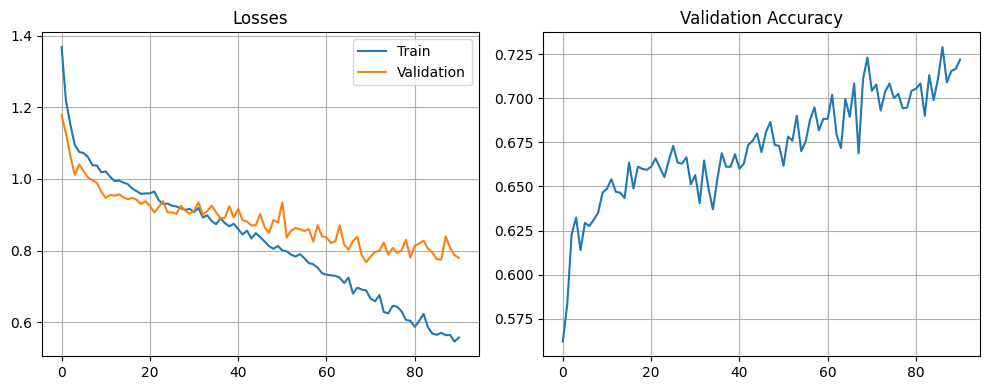

 92%|█████████▏| 92/100 [27:21<02:22, 17.76s/it]

Epoch 91: Train Loss = 0.5442, Val Loss = 0.8247, Val Acc = 0.7124


 93%|█████████▎| 93/100 [27:39<02:04, 17.74s/it]

Epoch 92: Train Loss = 0.5238, Val Loss = 0.8613, Val Acc = 0.7177


 94%|█████████▍| 94/100 [27:57<01:46, 17.72s/it]

...

Epoch 96: Train Loss = 0.5252, Val Loss = 0.8176, Val Acc = 0.7142


 98%|█████████▊| 98/100 [29:07<00:35, 17.69s/it]

Epoch 97: Train Loss = 0.4856, Val Loss = 0.8141, Val Acc = 0.7242


 99%|█████████▉| 99/100 [29:25<00:17, 17.69s/it]

Epoch 98: Train Loss = 0.4955, Val Loss = 0.8592, Val Acc = 0.7036
Epoch 99: Train Loss = 0.5065, Val Loss = 0.8257, Val Acc = 0.7148


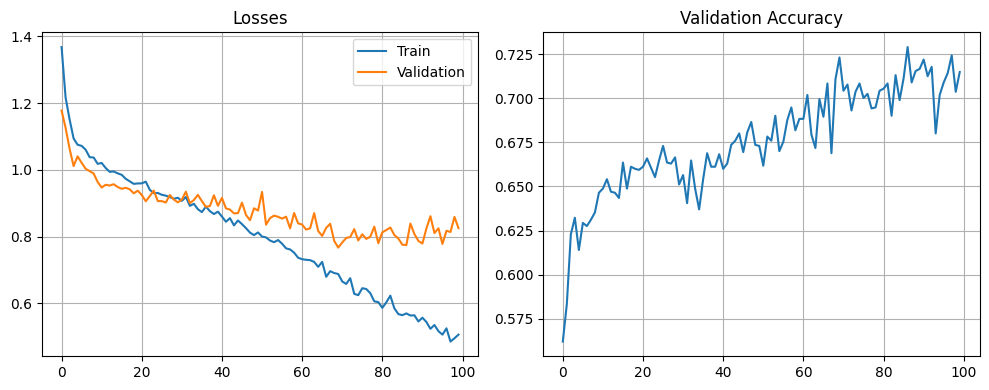

100%|██████████| 100/100 [29:43<00:00, 17.83s/it]


In [45]:
model = ic(CassavaClassifier(
    img_shape=(3, 256, 256),
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[256, 128, 64],
    output_dim=5
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
criterion = nn.CrossEntropyLoss()

model = train(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=100
)

In [48]:
model = CassavaClassifier(
    img_shape=(3, 256, 256),
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[256, 128, 64],
    output_dim=5
)

model.load_state_dict(torch.load('./models/best_model.pth'))
model.eval()
model

CassavaClassifier(
  (conv_part): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout2d(p=0.2, inplace=False)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.2, inplace=False)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [49]:
df_ss = pd.read_csv("./Data/sample_submission_file.csv")
df_ss.head()

,Category,Id
0,cbsd,test-img-0.jpg
1,cmd,test-img-1.jpg
2,cbb,test-img-2.jpg
3,cmd,test-img-3.jpg
4,cbsd,test-img-4.jpg


In [ ]:
paths = test_dataset.imgs
classes = train_dataset.classes

img_pred = dict()

model = model.cpu()
model.eval()

with torch.no_grad():
    for i in trange(len(test_dataset)):
        X = test_dataset[i][0]
        X = X.unsqueeze(0)
        
        name = os.path.basename(paths[i][0])
        
        pred = model(X)
        pred_class = pred.argmax(dim=1).item()
        
        img_pred[name] = classes[pred_class]

100%|██████████| 3774/3774 [01:57<00:00, 32.21it/s]


In [69]:
df_ss['Category'] = df_ss['Id'].map(img_pred)
df_ss.to_csv('./subms/subm.csv', index=False)